# Naive Bayes TF BOW Binary Dimensions
This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension).

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer  # <--- The key difference!
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

 --- STEP 1: Load Data  ---


In [25]:
print(" Loading data...")
current_dir = Path.cwd()
csv_path = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break
if not csv_path:
    csv_path = Path(r"C:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['posts', 'type'])

 Loading data...


 --- STEP 2: Vectorization (Bag of Words) ---

In [26]:
df = pd.read_csv(csv_path)
print(f"   Columns found: {df.columns.tolist()}")
text_col = 'posts' 
target_col = 'type'

# Remove rows where text or type is missing
df = df.dropna(subset=[text_col, target_col]) 

#Do NOT vectorize here. 
# We just pass the raw text list to the next step.
print("\n Preparing raw text for pipeline...")
X = df[text_col].values  # X is now a list of strings, not a matrix
y = df[target_col].values

print(f"Data shape: {X.shape[0]} rows")

   Columns found: ['type', 'posts', 'num_posts', 'no. of. words', 'type_encoded']

 Preparing raw text for pipeline...
Data shape: 8462 rows


--- STEP 3: Train & Evaluate  ---



 Starting Naive Bayes (BoW) with Grid Search Tuning

--- Tuning I vs E (BoW) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best F1-Score: 0.6161
Best Params: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'vect__max_features': 5000}
 Training F1: 0.7209
 Test F1:     0.6161
 Overfitting Gap: 10.48% (HIGH)
   Confusion Matrix (Full Data):
[[4924 1610]
 [ 483 1445]]

--- Tuning N vs S (BoW) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best F1-Score: 0.6122
Best Params: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'vect__max_features': 5000}
 Training F1: 0.7357
 Test F1:     0.6122
 Overfitting Gap: 12.35% (HIGH)
   Confusion Matrix (Full Data):
[[5924 1360]
 [ 256  922]]

--- Tuning T vs F (BoW) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best F1-Score: 0.7430
Best Params: {'classifier__alpha': 1.0, 'classifier__fit_prior': True, 'vect__max_features': 5000}
 Training F1: 0.7854
 Test F1:     0.7430
 Over

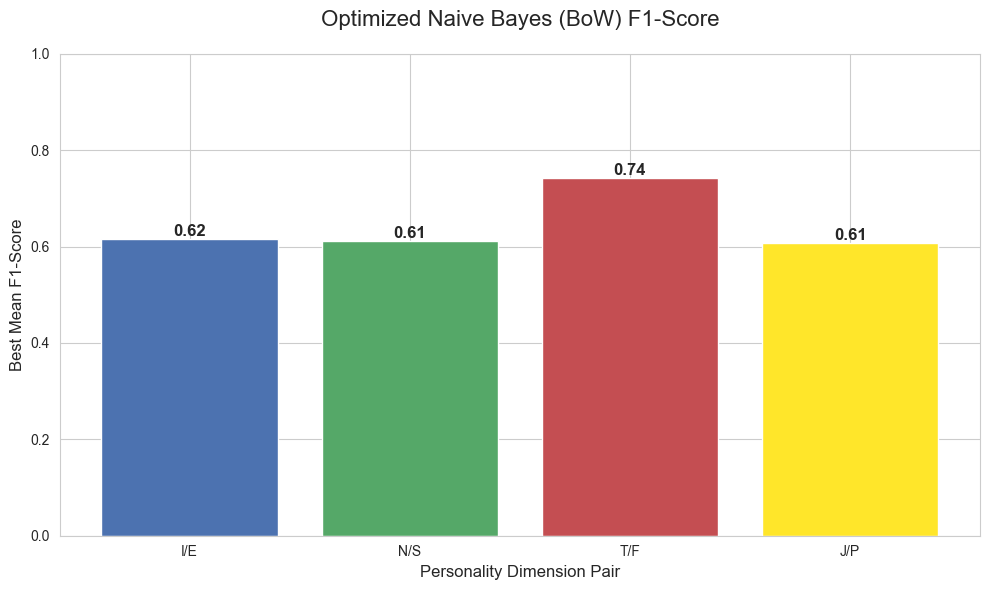


 Optimization Summary (BoW):
  I/E: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'vect__max_features': 5000}
  N/S: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'vect__max_features': 5000}
  T/F: {'classifier__alpha': 1.0, 'classifier__fit_prior': True, 'vect__max_features': 5000}
  J/P: {'classifier__alpha': 10.0, 'classifier__fit_prior': True, 'vect__max_features': 5000}

 Average Optimized F1-Score: 0.6448


In [27]:
print("\n Starting Naive Bayes (BoW) with Grid Search Tuning")

# Assuming X (raw text list) and y (full labels) are already loaded from Step 1 & 2

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
best_params_log = {}
best_gap_log = {}

# Set up 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline for Bag of Words
pipeline = ImbPipeline([
    ('vect', CountVectorizer(stop_words='english')), 
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', MultinomialNB())
])

param_grid = {
    'vect__max_features': [5000],      # removed None/2000 to keep consistent and save computation
    'classifier__alpha': [0.01, 1.0, 5.0, 10.0],   # BoW often likes higher alpha
    'classifier__fit_prior': [True, False]
}

sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\n--- Tuning {trait1} vs {trait2} (BoW) ---")
    
    # Create binary labels
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Initialize GridSearchCV
    # ADDED: return_train_score=True
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_macro', 
        n_jobs=-1,          
        verbose=1,
        return_train_score=True 
    )
    
    grid_search.fit(X, y_binary)
    
    # Store best results
    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    results[f"{trait1}/{trait2}"] = best_score
    best_params_log[f"{trait1}/{trait2}"] = best_params
    
    #Calculate and Print Overfitting Gap
    best_index = grid_search.best_index_
    train_score = grid_search.cv_results_['mean_train_score'][best_index]
    test_score = grid_search.cv_results_['mean_test_score'][best_index]
    gap = train_score - test_score
    best_gap_log[f"{trait1}/{trait2}"] = gap

    print(f"Best F1-Score: {best_score:.4f}")
    print(f"Best Params: {best_params}")
    print(f" Training F1: {train_score:.4f}")
    print(f" Test F1:     {test_score:.4f}")
    print(f" Overfitting Gap: {gap:.2%} ({'HIGH' if gap > 0.10 else 'OK'})")
    
    # Generate predictions on full dataset using the best model found
    y_pred_full = grid_search.predict(X)
    print(f"   Confusion Matrix (Full Data):\n{confusion_matrix(y_binary, y_pred_full)}")

#PLOTTING THE RESULTS
print("\n Generating Bar Graph of Best Scores (BoW)...")
plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

plt.title('Optimized Naive Bayes (BoW) F1-Score', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Best Mean F1-Score', fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#FINAL SUMMARY
print("\n Optimization Summary (BoW):")
for dim, params in best_params_log.items():
    print(f"  {dim}: {params}")

avg_f1 = sum(results.values()) / len(results)
print(f"\n Average Optimized F1-Score: {avg_f1:.4f}")

In [28]:
print("\n Starting Naive Bayes (BoW) - Optimizing for STABILITY (Low Overfitting)...")


dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results_stable = {}
best_params_stable = {}
best_stable_gap_dict = {}  # Store gaps for each dimension

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#CountVectorizer for BoW
pipeline = ImbPipeline([
    ('vect', CountVectorizer(stop_words='english')), 
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', MultinomialNB())
])

# We test high Alpha values here to force stability
param_grid = {
    'vect__max_features': [5000],
    'classifier__alpha': [0.1, 1.0, 5.0, 10.0, 20.0],
    'classifier__fit_prior': [True, False]
}

for trait1, trait2 in dimensions:
    print(f"\n--- Tuning {trait1} vs {trait2} (BoW) for Stability ---")
    
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # 1. Run Grid Search but keep the Train Scores!
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        return_train_score=True  # need this to check overfitting
    )
    
    # Fit on RAW text (pipeline handles vectorization)
    grid_search.fit(X, y_binary)
    
    # Extract Results
    cv_results = grid_search.cv_results_
    mean_test_scores = cv_results['mean_test_score']
    mean_train_scores = cv_results['mean_train_score']
    params = cv_results['params']
    
    #Find the "Most Stable" Parameter Set
    best_stable_gap = float('inf')
    best_stable_params = None
    best_stable_score = 0
    
    # Filter for models that are at least 90% as good as the absolute best F1
    max_f1 = np.max(mean_test_scores)
    threshold = max_f1 * 0.90 
    
    for i in range(len(params)):
        test_score = mean_test_scores[i]
        
        if test_score > threshold: # Only check "good" models
            train_score = mean_train_scores[i]
            gap = train_score - test_score 
            
            
            if gap < best_stable_gap:
                best_stable_gap = gap
                best_stable_params = params[i]
                best_stable_score = test_score

    # Save Results
    dim_name = f"{trait1}/{trait2}"
    results_stable[dim_name] = best_stable_score
    best_params_stable[dim_name] = best_stable_params
    best_stable_gap_dict[dim_name] = best_stable_gap  # Store in dictionary
    
    print(f"   Selected Alpha for Stability: {best_stable_params['classifier__alpha']}")
    print(f"   Test Score: {best_stable_score:.4f}")
    print(f"   Overfitting Gap: {best_stable_gap:.4f} ({(best_stable_gap*100):.2f}%)")

#SUMMARY 
print("\n Optimization Complete (BoW).")
print("Use these parameters to recreate Graph 5 (Low Overfitting - BoW):")
for dim, params in best_params_stable.items():
    print(f"  {dim}: {params}")



 Starting Naive Bayes (BoW) - Optimizing for STABILITY (Low Overfitting)...

--- Tuning I vs E (BoW) for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 20.0
   Test Score: 0.6144
   Overfitting Gap: 0.0875 (8.75%)

--- Tuning N vs S (BoW) for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 20.0
   Test Score: 0.5935
   Overfitting Gap: 0.1063 (10.63%)

--- Tuning T vs F (BoW) for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 20.0
   Test Score: 0.7386
   Overfitting Gap: 0.0401 (4.01%)

--- Tuning J vs P (BoW) for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 20.0
   Test Score: 0.6086
   Overfitting Gap: 0.0863 (8.63%)

 Optimization Complete (BoW).
Use these parameters to recreate Graph 5 (Low Overfitting - BoW):
  I/E: {'classifier__alpha': 

In [29]:
import joblib

# Prepare model data in compatible format for comparison notebook
model_data = {
    'dimensions': list(results_stable.keys()),
    
    # Comprehensive metrics from stability optimization
    'metrics': {dim: {
        'f1_score': results_stable[dim]*100,
        'overfit_gap': best_gap_log[dim]*100,
    } for dim in results_stable},
    
    # Stability optimization results
    'best_params': {dim: best_params_stable[dim] for dim in best_params_stable},
    'gridsearch_stable_f1': {dim: results_stable[dim] for dim in results_stable},
    'gridsearch_stable_gaps': {dim: best_gap_log[dim] for dim in best_gap_log},
    'gridsearch_stable_params': {dim: best_params_stable[dim] for dim in best_params_stable},
    
    'optimization_type': 'stability',
    'model_type': 'Naive Bayes (BOW)',
    'hyperparameters': {
        'vectorizer': 'CountVectorizer',
        'max_features': 5000,
        'stop_words': 'english',
        'upsampling': True,
        'optimization': 'Stability (Low Overfitting)',
        'selection_criteria': 'Minimum overfitting gap among models within 90% of best F1'
    }
}

# Save
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)
save_path = models_dir / 'naive_bayes_BOW_stability_ng.pkl'
joblib.dump(model_data, save_path)

print(f"\n✓ Model data saved to: {save_path}")
print(f"  Contains {len(model_data['dimensions'])} dimension classifiers")
print(f"  Average F1: {np.mean(list(results_stable.values())):.4f}")
print(f"  Average Overfitting Gap: {np.mean(list(best_stable_gap_dict.values())):.2%}")


✓ Model data saved to: ..\models\naive_bayes_BOW_stability_ng.pkl
  Contains 4 dimension classifiers
  Average F1: 0.6388
  Average Overfitting Gap: 8.01%
